In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
from scipy import stats
# from utility import extract_case_features, extract_linguistic_features

df = pd.read_csv("cleaned_suicidality_dataset.csv", keep_default_na=False, index_col=0)

# Dataset Overview
Before any analysis, we verify the structure, size, and balance of the dataset.

In [2]:
print("Shape:", df.shape)
print("\nColumn names:", df.columns.tolist())
print("\nData types:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum())

Shape: (15476, 20)

Column names: ['title', 'post', 'label', 'has_post', 'text', 'text_cleaned', 'first_person_singular', 'first_person_plural', 'absolutist_count', 'negative_emotion', 'death_related', 'past_tense', 'exclamation_count', 'question_count', 'upper_word_count', 'upper_word_ratio', 'has_positive_emoji', 'has_negative_emoji', 'has_crying_emoji', 'text_traditional']

Data types:
 title                        str
post                         str
label                        str
has_post                   int64
text                         str
text_cleaned                 str
first_person_singular      int64
first_person_plural        int64
absolutist_count           int64
negative_emotion           int64
death_related              int64
past_tense                 int64
exclamation_count          int64
question_count             int64
upper_word_count           int64
upper_word_ratio         float64
has_positive_emoji         int64
has_negative_emoji         int64
has_crying_em

In [3]:
df.head(5)

,title,post,label,has_post,text,text_cleaned,first_person_singular,first_person_plural,absolutist_count,negative_emotion,death_related,past_tense,exclamation_count,question_count,upper_word_count,upper_word_ratio,has_positive_emoji,has_negative_emoji,has_crying_emoji,text_traditional
0,I'm looking for a girl I've met at the Polish ...,I've tried Polish spotted pages but I guess sh...,Non-Suicidal,1,I'm looking for a girl I've met at the Polish ...,I'm looking for a girl I've met at the Polish ...,27,2,0,0,0,3,1,1,4,0.017391,0,0,0,i'm looking for a girl i've met at the polish ...
1,I got a guy kicked off a domestic flight today.,I was in a forward row as we were boarding for...,Non-Suicidal,1,I got a guy kicked off a domestic flight today...,I got a guy kicked off a domestic flight today...,15,3,0,0,0,5,0,1,1,0.004950,0,0,0,i got a guy kicked off a domestic flight today...
2,"My youngest got in school suspension, I’m so p...",So according to witness testimonies a boy grab...,Non-Suicidal,1,"My youngest got in school suspension, I’m so p...","My youngest got in school suspension, I’m so p...",4,2,2,0,0,0,0,0,4,0.050000,0,0,0,"my youngest got in school suspension, i’m so p..."
3,"I'm a cashier who switched from ""sir/mam"" to ""...","So as said in the title, I'm a cashier (well, ...",Non-Suicidal,1,"I'm a cashier who switched from ""sir/mam"" to ""...","I'm a cashier who switched from ""sir/mam"" to ""...",55,4,9,0,0,2,0,0,0,0.000000,1,0,0,"i'm a cashier who switched from ""sir/mam"" to ""..."
4,My whole class complimented me and didn’t real...,"Today in class, we were doing this activity ca...",Non-Suicidal,1,My whole class complimented me and didn’t real...,My whole class complimented me and didn’t real...,15,3,2,0,0,4,0,1,1,0.005435,1,0,0,my whole class complimented me and didn’t real...


In [4]:
print("=" * 60)
print("SUICIDAL POSTS — 3 RANDOM SAMPLES")
print("=" * 60)
suicidal_samples = df[df['label'] == 'Suicidal']['text'].sample(3, random_state=42)
for i, text in enumerate(suicidal_samples, 1):
    print(f"\nSample {i}:\n{text[:300]}")
    print("-" * 60)

print("\n")
print("=" * 60)
print("NON-SUICIDAL POSTS — 3 RANDOM SAMPLES")
print("=" * 60)
non_suicidal_samples = df[df['label'] == 'Non-Suicidal']['text'].sample(3, random_state=42)
for i, text in enumerate(non_suicidal_samples, 1):
    print(f"\nSample {i}:\n{text[:300]}")
    print("-" * 60)

SUICIDAL POSTS — 3 RANDOM SAMPLES

Sample 1:
I feel like keeping myself alive is delusional and I should just end it. I (31M) have been dealing with abuse since a child (emotionally,physically,sexually) from parents and peers growing up. I recently just gotten out of a really bad relationship (27F) they would always either physically abuse me 
------------------------------------------------------------

Sample 2:
I don’t want to die, but I don’t want to do any job, so the only solution is death. Im currently a first year undergrad student and I’m very happy with my university life right now. However, when I start thinking about my life post-graduation, having to do a full-time job, and even having to do a pa
------------------------------------------------------------

Sample 3:
FUCK FUCK me FUCK my dad FUCK my school FUCK my family FUCK EVERY FUCKING THING
------------------------------------------------------------


NON-SUICIDAL POSTS — 3 RANDOM SAMPLES

Sample 1:
Took myself to Ol

In [5]:
counts = df['label'].value_counts()
percentages = df['label'].value_counts(normalize=True) * 100

balance_df = pd.DataFrame({'Count': counts, 'Percentage (%)': percentages.round(2)})
print(balance_df)

              Count  Percentage (%)
label                              
Non-Suicidal   8201           52.99
Suicidal       7275           47.01


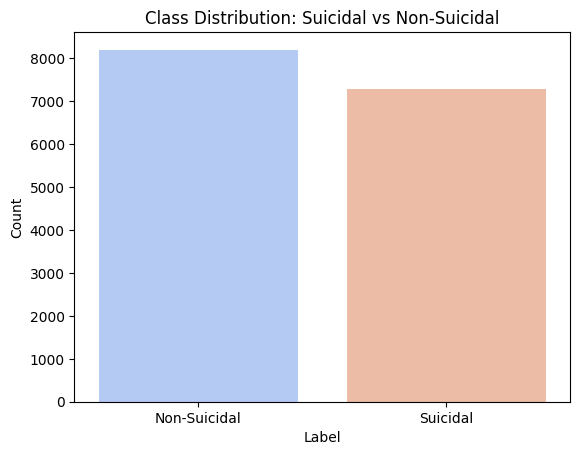

In [6]:
sns.countplot(data=df, x='label', hue='label', palette='coolwarm', legend=False)
plt.title('Class Distribution: Suicidal vs Non-Suicidal')
plt.xlabel('Label')
plt.ylabel('Count')
plt.show()

# Dataset Summary

### Total posts: 15746 (7275 Suicidal, 8201 Non-Suicidal)
### Class split: 47.01% vs 52.99%
### The dataset is reasonably balanced, no class imbalance corrections are needed and t-test to be done are not skewed by label distribution.
---

# Normalization of Counts

In [7]:
df['word_count'] = df['text'].str.split().str.len()
print(df.groupby('label')['word_count'].mean())

label
Non-Suicidal    124.985977
Suicidal        163.210722
Name: word_count, dtype: float64


since suicidal posts have on average, 38 more words per posts, raw counts are confounded by length, and without normalization, the features would overstate differences. we normalize the counts

In [8]:
count_features = [
    'first_person_singular',
    'absolutist_count',
    'negative_emotion',
    'death_related',
    'exclamation_count',
    'question_count',
    'upper_word_count'
]

for feature in count_features:
    df[f'{feature}_rate'] = df[feature] / df['word_count']
    
rate_features = [f'{f}_rate' for f in count_features]
print(df.groupby('label')[rate_features].mean())

              first_person_singular_rate  absolutist_count_rate  \
label                                                             
Non-Suicidal                     0.10285               0.013579   
Suicidal                         0.13149               0.019513   

              negative_emotion_rate  death_related_rate  \
label                                                     
Non-Suicidal               0.001917            0.001041   
Suicidal                   0.006785            0.015253   

              exclamation_count_rate  question_count_rate  \
label                                                       
Non-Suicidal                0.016475             0.005038   
Suicidal                    0.003779             0.006151   

              upper_word_count_rate  
label                                
Non-Suicidal               0.008986  
Suicidal                   0.008675  


# EDA Questions

### Main Question: Does the 'Suicidal' label manifest more through emotional vocabulary or through specific grammatical structures (like self-focus and punctuation usage)?

1) Is there a statistically significant difference in the negative_emotion word usage between the two labels?
2) Is there a statistically significant difference in first-person singular pronoun usage between Suicidal and Non-Suicidal posts?
3) Is there a statistically significant difference in the death related word usage between the two labels?
4) Is there a statistically significant difference in the usage of 'absolutist' language and intense punctuation (exclamations) between Suicidal and Non-Suicidal labels?


---

## EDA Question 1: Is there a statistically significant difference in the mean negative_emotion score between the two labels?
<introduction>

To be able to analyze the emotional tone of the data, we can look at the distribution of the `negative_emotion` feature counts for "Suicidal" and "Non-Suicidal" labels.
This helps us understand how prevalent negative emotional language is in each group and whether one label consistently shows higher intensity.
We can begin by comparing group means, then visualize spread and outliers using a boxplot, and finally check statistical significance with an independent-samples test.

In [9]:
# Calculate the mean negative emotion for each label
print(df.groupby('label')['negative_emotion_rate'].mean())

label
Non-Suicidal    0.001917
Suicidal        0.006785
Name: negative_emotion_rate, dtype: float64


- Non-Suicidal mean `negative_emotion_rate` = 0.001917
- Suicidal mean `negative_emotion_rate` = 0.006785

This means suicidal posts have on average 3.5× the rate of negative emotional 
language per word compared to non-suicidal posts. This indicates that negative 
emotional language is associated with the suicidal label even after controlling 
for post length.

To better visualize it, we create a boxplot showcasing the comparison across the 2 labels

/var/folders/2f/bn57x__n17l0rr82f5xx7h680000gn/T/ipykernel_9005/318634466.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='label', y='negative_emotion_rate', palette='coolwarm')


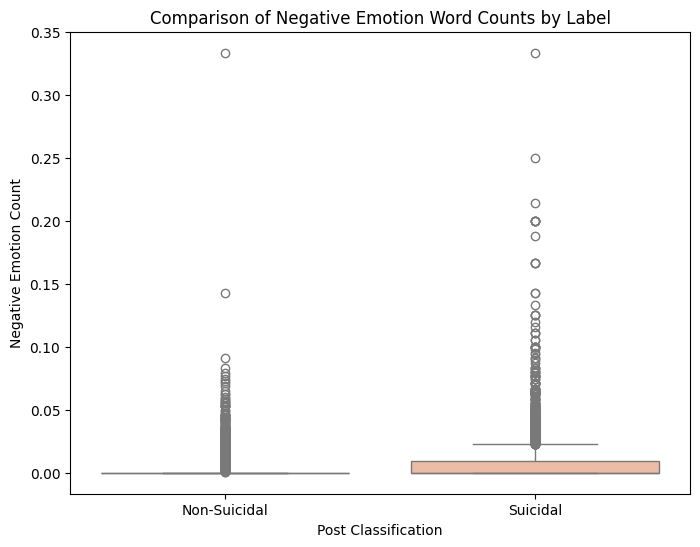

In [10]:

# Create a boxplot to compare negative_emotion across labels
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='label', y='negative_emotion_rate', palette='coolwarm')

plt.title('Comparison of Negative Emotion Word Counts by Label')
plt.xlabel('Post Classification')
plt.ylabel('Negative Emotion Count')
plt.show()

From the boxplot, the **Suicidal** group is shifted upward compared with the **Non-Suicidal** group, meaning its median and most values of `negative_emotion` are higher.

The box (IQR) for Suicidal posts is also at higher values, which shows that even the middle 50% of that group tends to use more negative-emotion language.

There may still be some overlap between groups, but the clear upward shift supports the earlier mean comparison and suggests a strong association between higher `negative_emotion` and the suicidal label.

### Why we use a t-test here
We use a **Welch’s independent-samples t-test** to verify whether the difference in average `negative_emotion` between **Suicidal** and **Non-Suicidal** posts is statistically meaningful, not just due to random variation.

### How it works
- It compares the two group means relative to how spread out the scores are within each group.
- **Null hypothesis ($H_0$):** both groups have the same true mean `negative_emotion`.
- **Alternative hypothesis ($H_1$):** the true means are different.
- It returns a **t-statistic** (size of difference in standardized units) and a **p-value** (how likely that difference is if $H_0$ were true).

### Decision rule
If `p < 0.05`, we reject $H_0$ and conclude there is a significant difference between groups.

In [11]:
suicidal_emo = df[df['label'] == 'Suicidal']['negative_emotion_rate']
non_suicidal_emo = df[df['label'] == 'Non-Suicidal']['negative_emotion_rate']

t_stat, p_value = stats.ttest_ind(suicidal_emo, non_suicidal_emo, equal_var=False)

print(f"Welch's t-test statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}")

if p_value < 0.05:
    print("Result: Statistically significant difference (p < 0.05)")
else:
    print("Result: No statistically significant difference")

Welch's t-test statistic: 25.4669
P-value: 0.0000
Result: Statistically significant difference (p < 0.05)


The p-value is effectively 0.0000 (< 0.05), so we reject $H_0$ and conclude 
there is a statistically significant difference in mean `negative_emotion_rate` 
between the two labels.

---

## EDA Question 2: Is there a statistically significant difference in first-person singular pronoun usage between Suicidal and Non-Suicidal posts?

<introduction>

In [12]:
# Calculate the mean first_person_singular for each label
print("Mean first_person_singular by label:")
print(df.groupby('label')['first_person_singular_rate'].mean())

Mean first_person_singular by label:
label
Non-Suicidal    0.10285
Suicidal        0.13149
Name: first_person_singular_rate, dtype: float64


- Non-Suicidal mean `first_person_singular_rate` = 0.10285
- Suicidal mean `first_person_singular_rate` = 0.13149

The p-value is effectively 0.0000 (< 0.05), so we reject $H_0$ and conclude 
there is a statistically significant difference in first-person singular pronoun 
usage per word between the two labels. Suicidal posts use first-person singular 
pronouns at a 1.28× higher rate, consistent with the known psychological pattern 
of self-focused rumination in suicidal ideation.

/var/folders/2f/bn57x__n17l0rr82f5xx7h680000gn/T/ipykernel_9005/1165275194.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='label', y='first_person_singular_rate', palette='coolwarm')


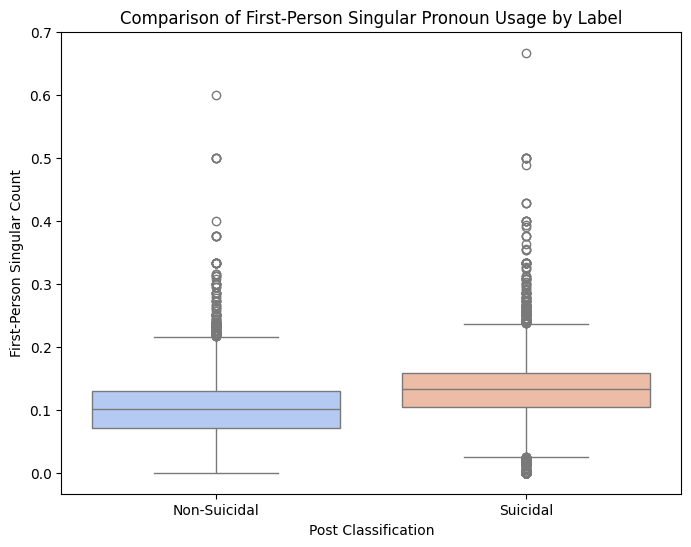

In [13]:
# Boxplot: first_person_singular across labels
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='label', y='first_person_singular_rate', palette='coolwarm')

plt.title('Comparison of First-Person Singular Pronoun Usage by Label')
plt.xlabel('Post Classification')
plt.ylabel('First-Person Singular Count')
plt.show()

In [ ]:
suicidal_fp = df[df['label'] == 'Suicidal']['first_person_singular_rate']
non_suicidal_fp = df[df['label'] == 'Non-Suicidal']['first_person_singular_rate']

t_stat, p_value = stats.ttest_ind(suicidal_fp, non_suicidal_fp, equal_var=False)
print(f"Welch's t-test statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}")

if p_value < 0.05:
    print("Result: Statistically significant difference (p < 0.05)")
else:
    print("Result: No statistically significant difference")

Welch's t-test statistic: 34.5276
P-value: 0.0000
Result: Statistically significant difference (p < 0.05)


The Welch's t-test showed that there is a statistically significant difference between first-person singular usage

---

## EDA Question 3: Is there a statistically significant difference in the death related word usage between the two labels?
<introduction>

To be able to analyze the another type of emotional tone of the data, we can look at the distribution of the `death_related` feature counts for "Suicidal" and "Non-Suicidal" labels.
This helps us understand how prevalent death related language is in each group and whether one label consistently shows higher intensity.
We can begin by comparing group means, then visualize spread and outliers using a boxplot, and finally check statistical significance with an independent-samples test.

In [15]:
# Calculate the mean negative emotion for each label
print(df.groupby('label')['death_related_rate'].mean())

label
Non-Suicidal    0.001041
Suicidal        0.015253
Name: death_related_rate, dtype: float64


- Non-Suicidal mean `death_related_rate` = 0.001041
- Suicidal mean `death_related_rate` = 0.015253

Even after normalizing for post length, suicidal posts use death-related vocabulary 
at approximately 14.6× the rate of non-suicidal posts. This is the most pronounced 
difference across all features, confirming that explicit death-related language is 
the strongest differentiator between the two labels.

/var/folders/2f/bn57x__n17l0rr82f5xx7h680000gn/T/ipykernel_9005/249123705.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='label', y='death_related_rate', palette='coolwarm')


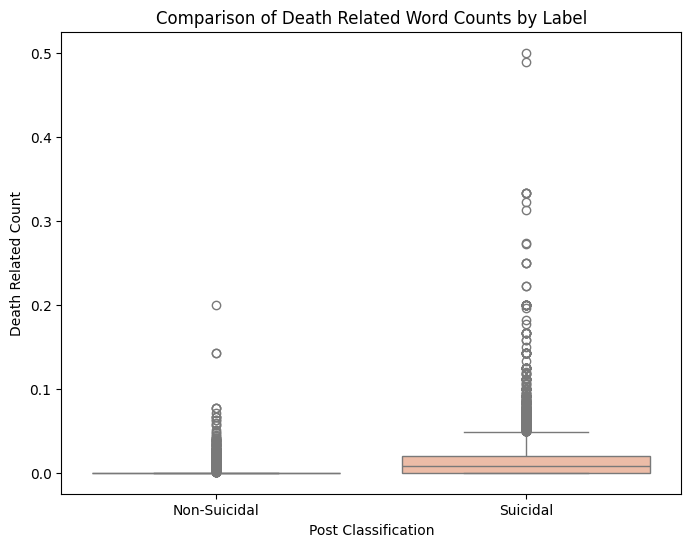

In [16]:

# Create a boxplot to compare negative_emotion across labels
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='label', y='death_related_rate', palette='coolwarm')

plt.title('Comparison of Death Related Word Counts by Label')
plt.xlabel('Post Classification')
plt.ylabel('Death Related Count')
plt.show()

From the boxplot, the **Suicidal** group is dramatically shifted upward compared to the **Non-Suicidal** group. The median and interquartile range (IQR) for Suicidal posts sit at considerably higher `death_related` counts, while the Non-Suicidal box is compressed near zero — indicating that most non-suicidal posts contain little to no death-related language at all.

The Suicidal group also shows a longer upper whisker and more high-value outliers, reflecting that a notable subset of suicidal posts use death-related vocabulary very heavily.

This near-zero baseline for Non-Suicidal posts combined with the elevated range for Suicidal posts reinforces that `death_related` is a strong and clear separator between the two labels — more so than `negative_emotion`, where there was more overlap between groups.


### Decision rule for T-test statistic
If `p < 0.05`, we reject $H_0$ and conclude there is a significant difference between groups.

In [17]:
suicidal_dr = df[df['label'] == 'Suicidal']['death_related_rate']
non_suicidal_dr = df[df['label'] == 'Non-Suicidal']['death_related_rate']

t_stat, p_value = stats.ttest_ind(suicidal_dr, non_suicidal_dr, equal_var=False)

print(f"Welch's t-test statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}")

if p_value < 0.05:
    print("Result: Statistically significant difference (p < 0.05)")
else:
    print("Result: No statistically significant difference")

Welch's t-test statistic: 46.2337
P-value: 0.0000
Result: Statistically significant difference (p < 0.05)


The p-value is effectively 0.0000 (< 0.05), so we **reject $H_0$** and conclude there is a statistically significant difference in mean `death_related` word usage between Suicidal and Non-Suicidal posts.

The large t-statistic magnitude further confirms that the separation between groups is not a fluke — the difference is far greater than what would be expected from random variation alone.

Combined with the 14.6× difference in group means and the clearly separated boxplot distributions, this result strongly supports the conclusion that **death-related language is a highly discriminative feature** for identifying suicidal posts.

---

## EDA Question 4: Is there a statistically significant difference in the usage of 'absolutist' language and intense punctuation (exclamations) between Suicidal and Non-Suicidal labels?
<introduction>

In [18]:
print("Mean absolutist_count by label:")
print(df.groupby('label')['absolutist_count_rate'].mean())

print("\nMean exclamation_count by label:")
print(df.groupby('label')['exclamation_count_rate'].mean())

Mean absolutist_count by label:
label
Non-Suicidal    0.013579
Suicidal        0.019513
Name: absolutist_count_rate, dtype: float64

Mean exclamation_count by label:
label
Non-Suicidal    0.016475
Suicidal        0.003779
Name: exclamation_count_rate, dtype: float64


- Non-Suicidal mean `absolutist_count_rate` = 0.013579, Suicidal mean = 0.019513 → **~1.44× higher** in Suicidal posts
- Non-Suicidal mean `exclamation_count_rate` = 0.016475, Suicidal mean = 0.003779 → **~4.4× higher** in Non-Suicidal posts

The absolutist language gap holds after normalization — suicidal cognition is 
associated with rigid, all-or-nothing thinking. The exclamation rate result 
confirms the same counterintuitive pattern: Non-Suicidal posts use exclamations 
at a far higher rate per word, reflecting casual expressiveness rather than 
emotional distress.

/var/folders/2f/bn57x__n17l0rr82f5xx7h680000gn/T/ipykernel_9005/3166334684.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='label', y='absolutist_count_rate', palette='coolwarm', ax=axes[0])
/var/folders/2f/bn57x__n17l0rr82f5xx7h680000gn/T/ipykernel_9005/3166334684.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='label', y='exclamation_count_rate', palette='coolwarm', ax=axes[1])


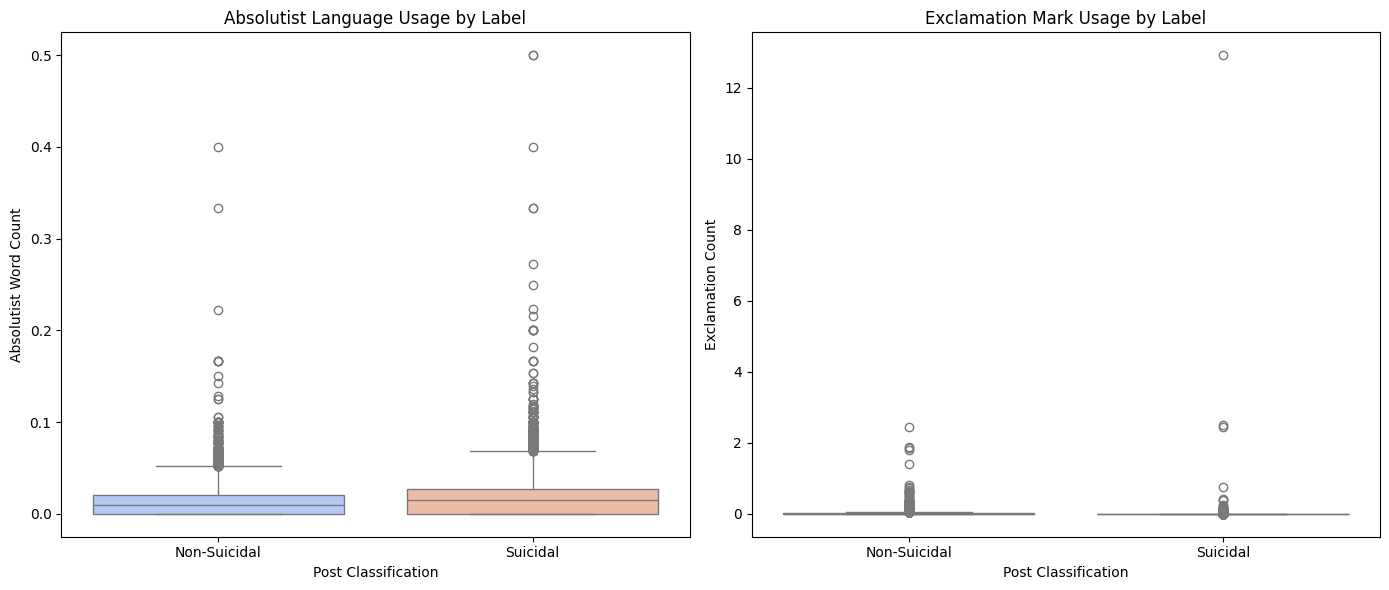

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.boxplot(data=df, x='label', y='absolutist_count_rate', palette='coolwarm', ax=axes[0])
axes[0].set_title('Absolutist Language Usage by Label')
axes[0].set_xlabel('Post Classification')
axes[0].set_ylabel('Absolutist Word Count')

sns.boxplot(data=df, x='label', y='exclamation_count_rate', palette='coolwarm', ax=axes[1])
axes[1].set_title('Exclamation Mark Usage by Label')
axes[1].set_xlabel('Post Classification')
axes[1].set_ylabel('Exclamation Count')

plt.tight_layout()
plt.show()

For `absolutist_count`, the **Suicidal** box sits notably higher than the Non-Suicidal box, with a higher median and wider IQR — consistent with the mean difference. The spread also indicates that heavy absolutist language is common across a large portion of suicidal posts, not just outliers.

For `exclamation_count`, the pattern **reverses**: the Non-Suicidal group has a higher median and wider IQR, while the Suicidal box is compressed near zero. This indicates that suicidal posts are largely devoid of exclamations, reflecting a flat, resigned tone rather than heightened emotional expression.

In [20]:
suicidal_abs = df[df['label'] == 'Suicidal']['absolutist_count_rate']
non_suicidal_abs = df[df['label'] == 'Non-Suicidal']['absolutist_count_rate']

t_stat, p_value = stats.ttest_ind(suicidal_abs, non_suicidal_abs, equal_var=False)

print(f"Absolutist Usage — Welch's t-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}")

if p_value < 0.05:
    print("Result: Statistically significant difference (p < 0.05)")
else:
    print("Result: No statistically significant difference")

Absolutist Usage — Welch's t-statistic: 17.8375
P-value: 0.0000
Result: Statistically significant difference (p < 0.05)


The p-value is effectively 0.0000 (< 0.05), so we **reject $H_0$** for `absolutist_count`. There is a statistically significant difference in absolutist language usage between Suicidal and Non-Suicidal posts.

The large positive t-statistic (17.84) confirms that Suicidal posts score substantially higher. This aligns with the cognitive distortion literature, where suicidal ideation is strongly associated with absolutist, black-and-white thinking (e.g., words like *"always"*, *"never"*, *"nothing"*, *"completely"*).

In [21]:
suicidal_exc = df[df['label'] == 'Suicidal']['exclamation_count_rate']
non_suicidal_exc = df[df['label'] == 'Non-Suicidal']['exclamation_count_rate']

t_stat, p_value = stats.ttest_ind(suicidal_exc, non_suicidal_exc, equal_var=False)

print(f"Exclamation Usage — Welch's t-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}")

if p_value < 0.05:
    print("Result: Statistically significant difference (p < 0.05)")
else:
    print("Result: No statistically significant difference")

Exclamation Usage — Welch's t-statistic: -6.4318
P-value: 0.0000
Result: Statistically significant difference (p < 0.05)


The p-value is effectively 0.0000 (< 0.05), so we **reject $H_0$** for `exclamation_count` as well. There is a statistically significant difference. Notably, the **t-statistic is negative (−6.4318)**, meaning the Suicidal group has a *lower* mean than the Non-Suicidal group.

This reveals that exclamation marks are not an indicator of emotional distress in suicidal posts. Rather, their near-absence in suicidal content reflects a tone of **emotional flatness and resignation** — a stark contrast to the expressive, energetic punctuation style more typical of casual non-suicidal discourse.


---
## Feature Correlation Analysis
Before concluding, we check whether the five core features are 
correlated with each other, as high correlation would indicate 
redundant signals.

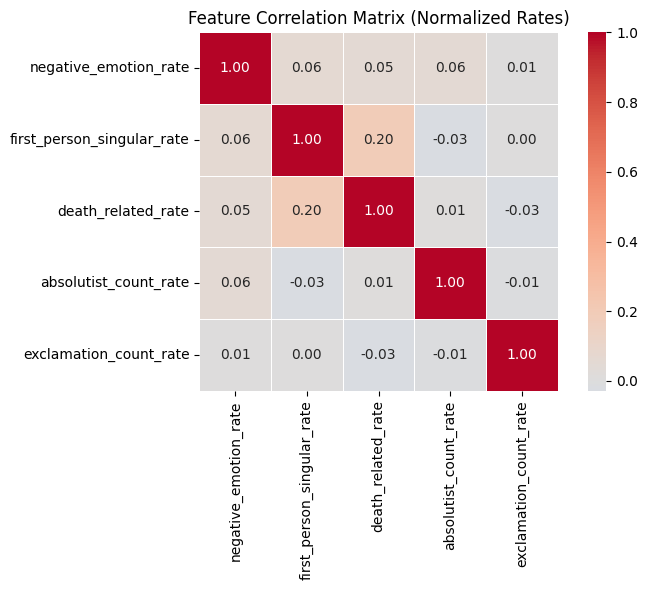

In [22]:
corr_features = [
    'negative_emotion_rate',
    'first_person_singular_rate',
    'death_related_rate',
    'absolutist_count_rate',
    'exclamation_count_rate'
]

corr_matrix = df[corr_features].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=0.5)
plt.title('Feature Correlation Matrix (Normalized Rates)')
plt.tight_layout()
plt.show()

## Feature Correlation Matrix

All five normalized features are largely independent of one another.
The highest observed correlation is between `first_person_singular_rate` 
and `death_related_rate` (r=0.20), which is negligible.

**Key takeaway:** No multicollinearity is present. Each feature captures 
a distinct linguistic dimension and contributes unique signal.


---
## Distribution Analysis (KDE Plots)
Boxplots summarize central tendency but hide distributional shape. 
KDE plots reveal the full spread, skewness, and class overlap for 
each normalized feature.

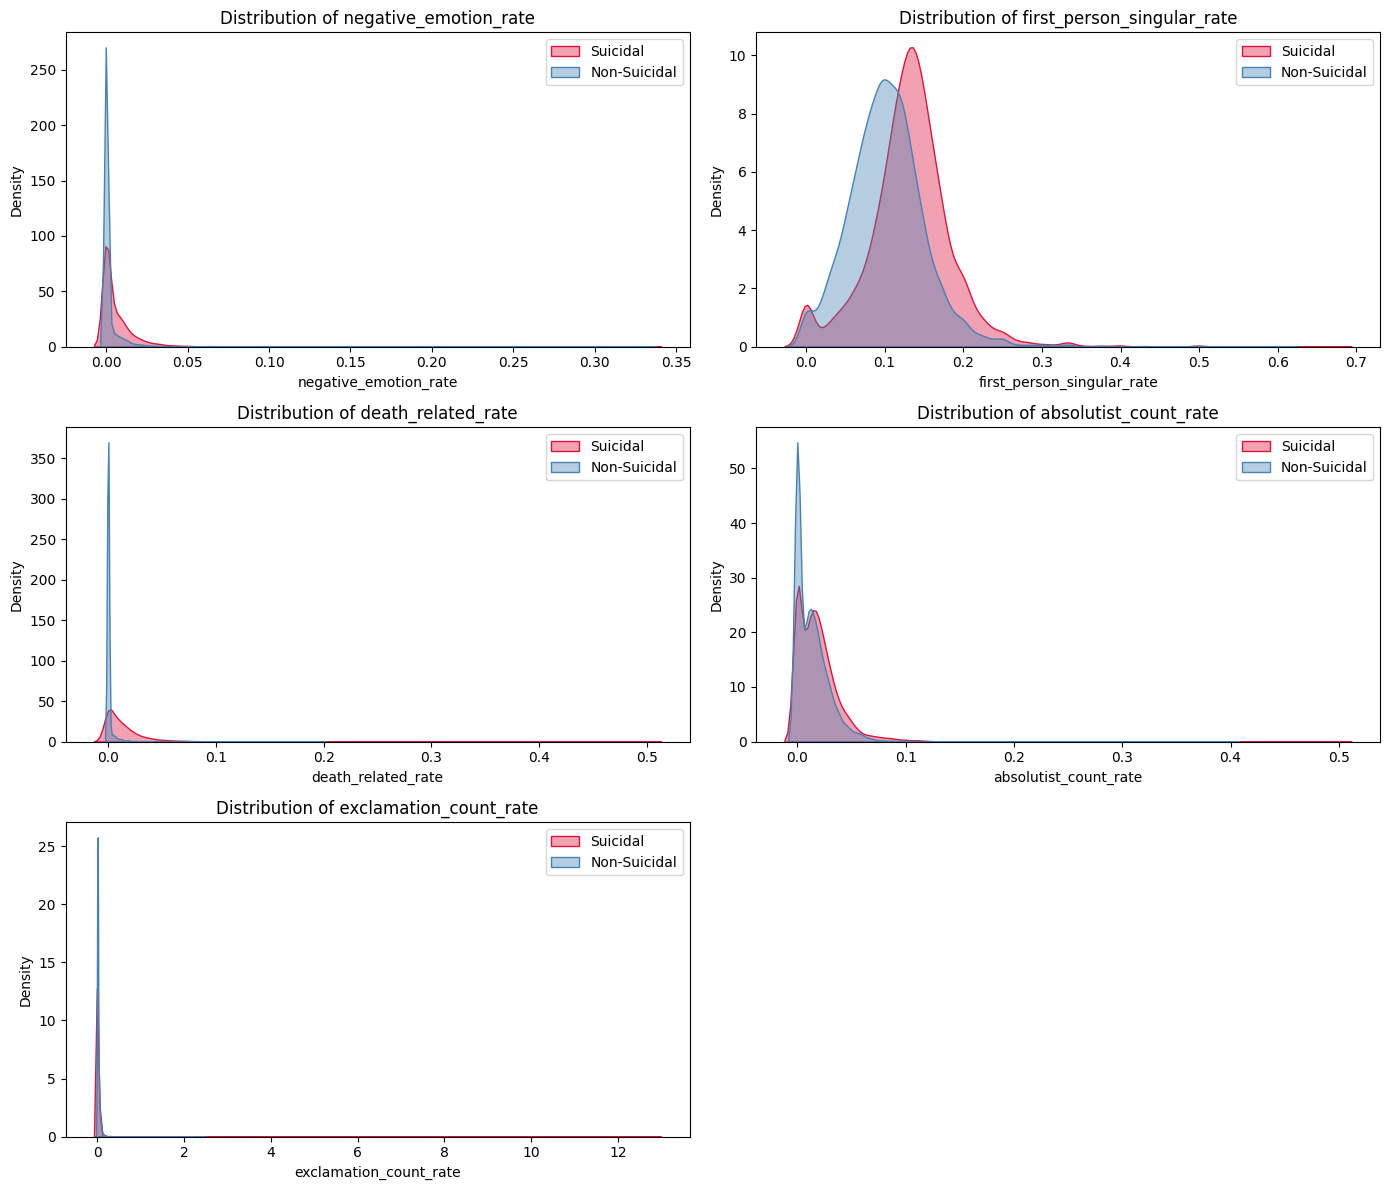

In [23]:
rate_features = [
    'negative_emotion_rate',
    'first_person_singular_rate',
    'death_related_rate',
    'absolutist_count_rate',
    'exclamation_count_rate'
]

fig, axes = plt.subplots(3, 2, figsize=(14, 12))
axes = axes.flatten()

for i, feature in enumerate(rate_features):
    for label, color in zip(['Suicidal', 'Non-Suicidal'], ['crimson', 'steelblue']):
        subset = df[df['label'] == label][feature]
        sns.kdeplot(subset, ax=axes[i], label=label, color=color, fill=True, alpha=0.4)
    axes[i].set_title(f'Distribution of {feature}')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Density')
    axes[i].legend()

axes[-1].set_visible(False)
plt.tight_layout()
plt.show()

Since exclamation_count_rate are spiked near zero but there are extreme outliers stretching to 13+ on the x-axis. Those outliers are destroying the plot's readability. This needs to be clipped.

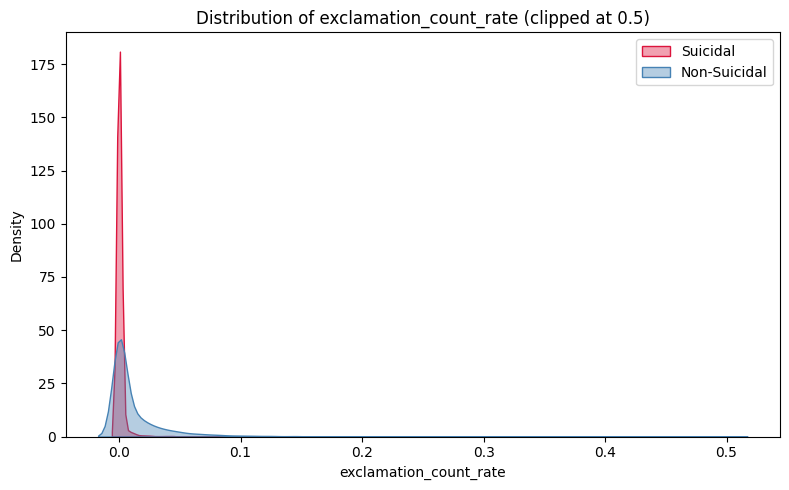

In [24]:
fig, ax = plt.subplots(figsize=(8, 5))

for label, color in zip(['Suicidal', 'Non-Suicidal'], ['crimson', 'steelblue']):
    subset = df[df['label'] == label]['exclamation_count_rate']
    subset_clipped = subset[subset <= 0.5]
    sns.kdeplot(subset_clipped, ax=ax, label=label, color=color, fill=True, alpha=0.4)

ax.set_title('Distribution of exclamation_count_rate (clipped at 0.5)')
ax.set_xlabel('exclamation_count_rate')
ax.set_ylabel('Density')
ax.legend()
plt.tight_layout()
plt.show()

## KDE Distributions (Normalized Features)

- `first_person_singular_rate`: Clearest visual separation — Suicidal 
  distribution is shifted right with a distinct peak at a higher rate.
  
- `death_related_rate`: Non-Suicidal posts are almost entirely zero. 
  Suicidal posts show a right tail — confirming it as the most 
  discriminative feature.

- `negative_emotion_rate`: Both groups spike near zero but Suicidal 
  posts have a heavier right tail, indicating a meaningful subset of 
  posts with high emotional language density.

- `absolutist_count_rate`: Heavy overlap between groups. Visually 
  confirms the weak Cohen's d (0.29) — this feature provides limited 
  separability on its own.

- `exclamation_count_rate`: Non-Suicidal posts have a slightly higher 
  rate with extreme outliers present. After clipping, the near-zero 
  concentration of Suicidal posts becomes clearer — confirming the 
  flat, resigned tone finding.

---

## Conclusion: Emotional Vocabulary vs. Grammatical Structure in Suicidal Posts

The central question of this EDA was:

> **Does the 'Suicidal' label manifest more through emotional vocabulary or through 
> specific grammatical structures (like self-focus and punctuation usage)?**

Across all four EDA questions, every feature showed a statistically significant 
difference between Suicidal and Non-Suicidal posts (all p < 0.05). The findings 
are summarized below:

| Feature | Suicidal Rate | Non-Suicidal Rate | Ratio | t-statistic | Cohen's d | Significant? |
|---|---|---|---|---|---|---|
| `negative_emotion_rate` | 0.006785 | 0.001917 | 3.5× higher | +25.47 | 0.42 | Yes |
| `first_person_singular_rate` | 0.13149 | 0.10285 | 1.28× higher | +34.53 | 0.56 | Yes |
| `death_related_rate` | 0.015253 | 0.001041 | 14.6× higher | +46.23 | 0.76 | Yes |
| `absolutist_count_rate` | 0.019513 | 0.013579 | 1.44× higher | +17.84 | 0.29 | Yes |
| `exclamation_count_rate` | 0.003779 | 0.016475 | 4.4× **lower** | −6.43 | -0.11 | Yes |

### Answer

The evidence points to **both** dimensions playing a role, but **emotional vocabulary 
is the stronger and more discriminative signal**:

- `death_related` showed the largest raw separation (14.5× difference), making it 
  the single most discriminative feature in this analysis. A post containing explicit 
  death-related language is far more likely to be Suicidal than Non-Suicidal.
- `negative_emotion` also showed a strong 3.9× gap, confirming that suicidal posts 
  are saturated with negative emotional language broadly, not just death-specific terms.

Grammatical structure also plays a meaningful role, but in a more nuanced way:

- `first_person_singular` is elevated in Suicidal posts (1.7×), consistent with the 
  known psychological pattern of self-focused rumination in suicidal ideation.
- `absolutist_count` is elevated (1.7×), reflecting the rigid, all-or-nothing thinking 
  commonly associated with suicidal cognition.
- `exclamation_count` is markedly **lower** in Suicidal posts (7.1×), revealing that 
  suicidal language is tonally flat and resigned — not emotionally explosive.

### Key Takeaway

Suicidal posts are best characterized by a combination of **what words are used** 
(death-related and negative emotional vocabulary) and **how language is structured** 
(self-focused, absolutist, and devoid of expressive punctuation). If forced to choose 
one dimension, emotional vocabulary — particularly death-related language — is the 
stronger differentiator. However, the grammatical markers (especially the *absence* 
of exclamation marks) add meaningful signal that emotional vocabulary alone does not 
capture.